In [45]:
# ── SECTION 1: Load & Overview ─────────────────────
# Load titanic_clean.csv
# Print shape, columns, missing values, describe

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic_clean.csv")
print(" Shape: ", df.shape)
print(" \nColumns: ", df.columns.to_list())
print(" \nNull Values: ", df.isnull().sum() )
print("\nStats: ", df.describe() )

 Shape:  (891, 11)
 
Columns:  ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'age_group', 'family_size', 'fare_category']
 
Null Values:  Survived         0
Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Fare             0
Embarked         0
age_group        0
family_size      0
fare_category    0
dtype: int64

Stats:           Survived      Pclass         Age       SibSp       Parch        Fare  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208   
std      0.486592    0.836071   13.002015    1.102743    0.806057   49.693429   
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000   
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.910400   
50%      0.000000    3.000000   29.699118    0.000000    0.000000   14.454200   
75%      1.000000    3.000000   35.

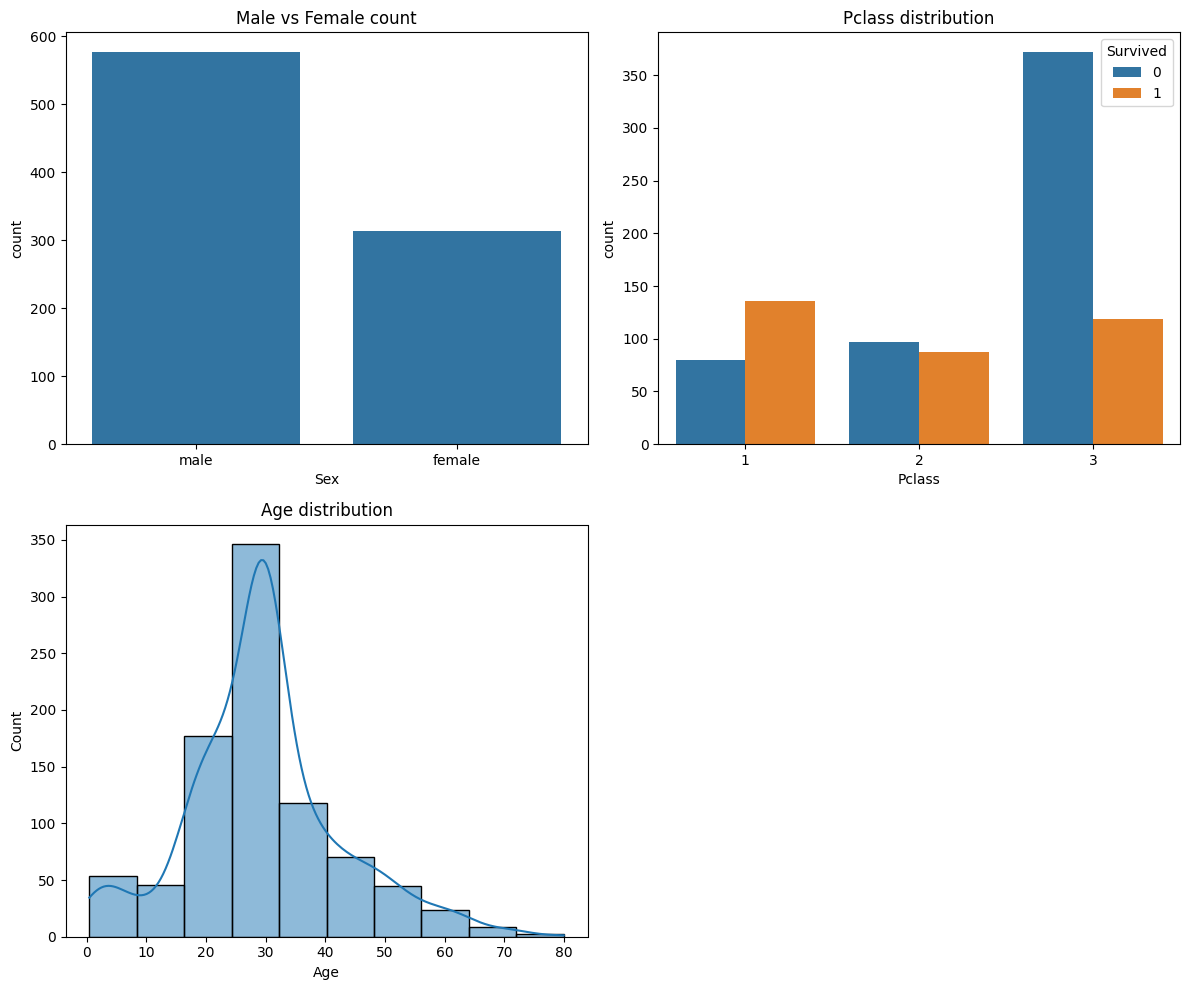

In [46]:
# ── SECTION 2: Passenger Overview ──────────────────
# Chart 1: countplot — Male vs Female count
# Chart 2: countplot — Pclass distribution
# Chart 3: histplot — Age distribution (kde=True)
# Insight: Who were the passengers?

fig, axes = plt.subplots(2,2, figsize = (12,10))
sns.countplot(x="Sex", data=df , ax=axes[0,0])
axes[0,0].set_title("Male vs Female count")

sns.countplot(x="Pclass", hue="Survived", data=df , ax=axes[0,1])
axes[0,1].set_title("Pclass distribution")

sns.histplot(x="Age",bins=10, data=df , kde=True, ax=axes[1,0])
axes[1,0].set_title("Age distribution")

axes[1,1].remove()
plt.tight_layout()
plt.show()

# - More males (577) than females (314)
# - 3rd class had most passengers
# - Most passengers aged between 20-40


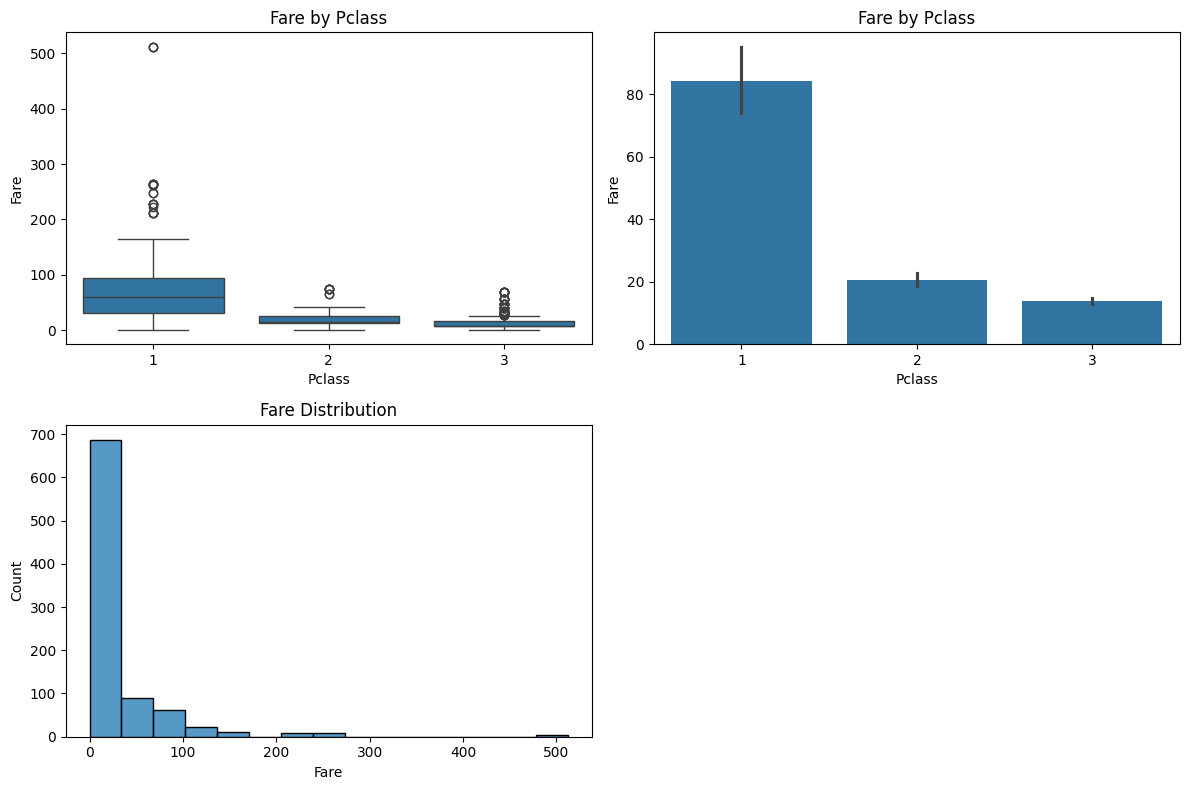

In [47]:
# ── SECTION 3: Fare & Class Analysis ───────────────
# Chart 4: boxplot — Fare by Pclass (outliers!)
# Chart 5: barplot — Average fare by Pclass
# Chart 6: histplot — Fare distribution

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(x="Pclass", y="Fare",data=df , ax=axes[0,0])
axes[0,0].set_title("Fare by Pclass")

sns.barplot(x="Pclass", y="Fare",data=df , ax=axes[0,1])
axes[0,1].set_title("Fare by Pclass")

sns.histplot(df["Fare"],bins=15, ax=axes[1,0])
axes[1,0].set_title("Fare Distribution")

axes[1,1].remove()
plt.tight_layout()
plt.show()

# - 1st class paid highest fare (avg ~87)
# - 3rd class paid lowest fare (avg ~13)
# - Most passengers paid between 0-50
# - Fare distribution is right skewed


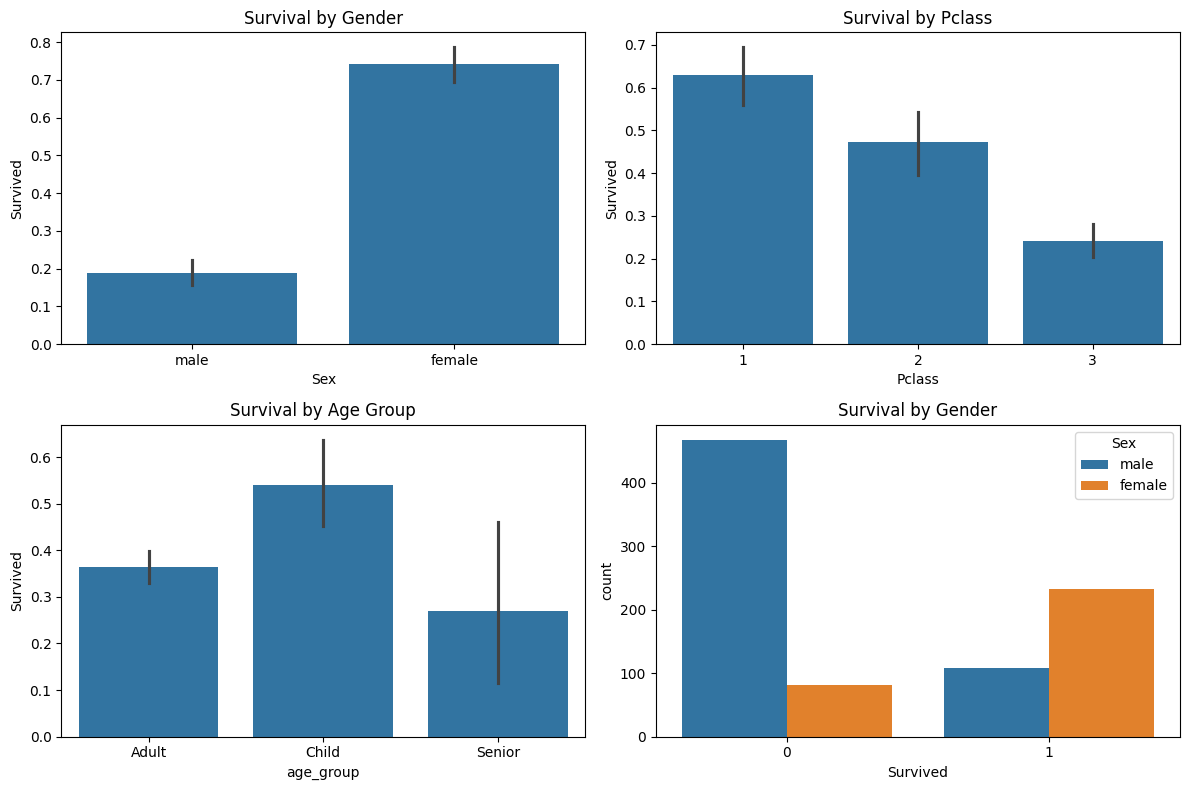

In [48]:
# ── SECTION 4: Survival Analysis ───────────────────
# Chart 7: barplot — Survival by Gender
# Chart 8: barplot — Survival by Pclass
# Chart 9: barplot — Survival by Age Group
# Chart 10: countplot — Survived with hue=Sex
# Insight: Who survived and why?

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.barplot(x="Sex", y="Survived",data=df , ax=axes[0,0])
axes[0,0].set_title("Survival by Gender")

sns.barplot(x="Pclass", y="Survived",data=df , ax=axes[0,1])
axes[0,1].set_title("Survival by Pclass")

sns.barplot(x="age_group", y="Survived",data=df , ax=axes[1,0])
axes[1,0].set_title("Survival by Age Group")

sns.countplot(x="Survived", hue="Sex",data=df , ax=axes[1,1])
axes[1,1].set_title("Survival by Gender")

plt.tight_layout()
plt.show()

# - Female survival (74%) >> Male survival (19%)
# - 1st class survived most, 3rd class least
# - Children had higher survival than adults
# - "Women and children first" visible in data

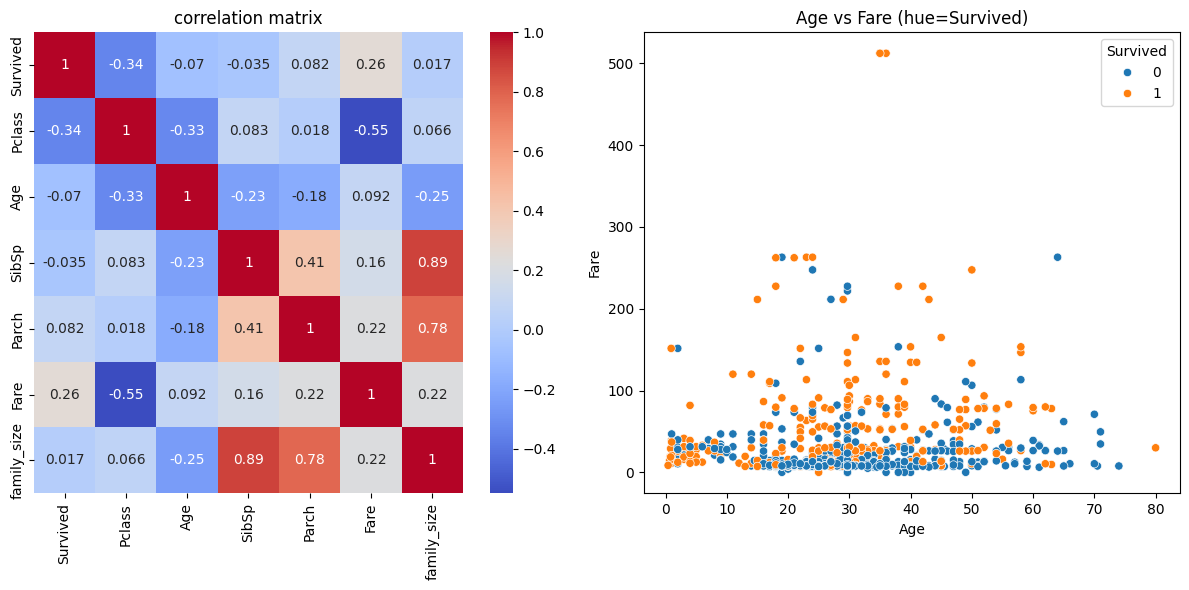

In [49]:
# ─────────── SECTION 5: Correlation & Relationships ─────────
# Chart 11: heatmap — correlation matrix
# Chart 12: scatter — Age vs Fare (hue=Survived)
# Insight: What relationships exist?


fig, axes = plt.subplots(1,2, figsize=(12,6))

numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm" , ax=axes[0])
axes[0].set_title("correlation matrix")

sns.scatterplot(x="Age", y="Fare",  hue="Survived",data=df,ax=axes[1])
axes[1].set_title( "Age vs Fare (hue=Survived)")

plt.tight_layout()
plt.show()


# - family_size & SibSp highly correlated (0.89)
# - Pclass & Fare negatively correlated (-0.55)
# - High fare passengers survived more
# - 3rd class low fare = lower survival

In [ ]:
# ──────── 📌 FINAL SUMMARY — What I would tell a stakeholder ──────────

# 1. GENDER: Female passengers had 74% survival vs male 19%
#    → "Women and children first" policy saved more females

# 2. CLASS: 1st class had 63% survival vs 3rd class 24%
#    → Wealthier passengers had better access to lifeboats

# 3. AGE: Children survived more than adults
#    → Age was a priority factor in rescue operations

# 4. FARE: Most passengers paid low fare (0-50 range)
#    → Majority were budget/3rd class travelers

# 5. EMBARKATION: Cherbourg (C) passengers survived most
#    → More 1st class passengers boarded from Cherbourg

# 6. FAMILY: Solo travelerss and small families survived more
#    → Large families struggled to evacuate together

# 7. CORRELATION: family_size & SibSp are redundant (0.89)
#    → In ML model we should drop one of these columns